**Name: Sharon Princy S**    
**Title: Customer Churn**

**Problem Statement**

A DTH provider is facing high competition and struggling to retain its existing accounts. Since each account may contain multiple customers, losing even one account leads to significant revenue loss. The company wants to build a churn prediction model to identify accounts likely to churn and design targeted, cost-efficient retention campaigns. Your task is to develop the churn model and propose business recommendations that effectively reduce churn without offering excessive or loss-making incentives, ensuring approval from the revenue assurance team.

**Objective**

The goal of this project is to develop a model that can accurately predict which DTH accounts are at risk of discontinuing their service. By identifying these accounts early, the business can intervene with targeted and financially sensible retention measures.

The objective is to minimize account churn, safeguard revenue, and enhance customer loyalty, while ensuring that the recommended actions remain cost-effective and aligned with the company’s profit goals.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
path="/content/drive/MyDrive/customer.csv"
df=pd.read_csv(path)
df.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,160,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,121,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,130,Mobile


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [ ]:
df.shape

(11260, 19)

In [ ]:
df.drop(['AccountID'], axis=1, inplace=True)

In [ ]:
print(df['Churn'].value_counts())

Churn
0    9364
1    1896
Name: count, dtype: int64


In [ ]:
df.describe()

,Churn,City_Tier,CC_Contacted_LY,Service_Score,CC_Agent_Score,Complain_ly
count,11260.000000,11148.000000,11158.000000,11162.000000,11144.000000,10903.000000
mean,0.168384,1.653929,17.867091,2.902526,3.066493,0.285334
std,0.374223,0.915015,8.853269,0.725584,1.379772,0.451594
min,0.000000,1.000000,4.000000,0.000000,1.000000,0.000000
25%,0.000000,1.000000,11.000000,2.000000,2.000000,0.000000
50%,0.000000,1.000000,16.000000,3.000000,3.000000,0.000000
75%,0.000000,3.000000,23.000000,3.000000,4.000000,1.000000
max,1.000000,3.000000,132.000000,5.000000,5.000000,1.000000


**Missing Value Treatment**

In [ ]:
df.isnull().sum()

,0
Churn,0
Tenure,102
City_Tier,112
CC_Contacted_LY,102
Payment,109
Gender,108
Service_Score,98
Account_user_count,112
account_segment,97
CC_Agent_Score,116


In [ ]:
df['Tenure'] = pd.to_numeric(df['Tenure'], errors='coerce')
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median()).astype('int64')

In [ ]:
df['City_Tier'] = df['City_Tier'].astype('category')

In [ ]:
df['City_Tier'] = df['City_Tier'].fillna(df['City_Tier'].mode()[0])

In [ ]:
df['CC_Contacted_LY'] = df['CC_Contacted_LY'].fillna(df['CC_Contacted_LY'].median())

In [ ]:
df['Payment'] = df['Payment'].fillna(df['Payment'].mode()[0])

In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [ ]:
df['Account_user_count'] = df['Account_user_count'].fillna(df['Account_user_count'].mode()[0])

In [ ]:
df['Service_Score'] = df['Service_Score'].fillna(df['Service_Score'].median())

In [ ]:
df['account_segment'] = df['account_segment'].fillna(df['account_segment'].mode()[0])

In [ ]:
df['CC_Agent_Score'] = df['CC_Agent_Score'].fillna(df['CC_Agent_Score'].median())

In [ ]:
df['Marital_Status'] = df['Marital_Status'].fillna(df['Marital_Status'].mode()[0])

In [ ]:
df['rev_per_month'] = pd.to_numeric(df['rev_per_month'],errors='coerce').astype('float64')

In [ ]:
df['rev_per_month'] = df['rev_per_month'].fillna(df['rev_per_month'].median())

In [ ]:
df['Complain_ly'] = df['Complain_ly'].fillna(df['Complain_ly'].median())

In [ ]:
df['Complain_ly'] = pd.to_numeric(df['Complain_ly'],errors='coerce').astype('int64')

In [ ]:
df['rev_growth_yoy'] = pd.to_numeric(df['rev_growth_yoy'], errors='coerce')
df['rev_growth_yoy'] = df['rev_growth_yoy'].fillna(df['rev_growth_yoy'].median()).astype('int64')

In [ ]:
df['coupon_used_for_payment'] = pd.to_numeric(df['coupon_used_for_payment'],errors='coerce')

In [ ]:
df['coupon_used_for_payment'] = df['coupon_used_for_payment'].fillna(df['coupon_used_for_payment'].median()).astype('int64')

In [ ]:
df['Day_Since_CC_connect'] = pd.to_numeric(df['Day_Since_CC_connect'],errors='coerce')

In [ ]:
df['Day_Since_CC_connect'] = df['Day_Since_CC_connect'].fillna(df['Day_Since_CC_connect'].median()).astype('int64')

In [ ]:
df['cashback'] = pd.to_numeric(df['cashback'],errors='coerce').astype('float64')

In [ ]:
df['cashback'] = df['cashback'].fillna(df['cashback'].median())

In [ ]:
df['Login_device'] = df['Login_device'].fillna(df['Login_device'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Churn,0
Tenure,0
City_Tier,0
CC_Contacted_LY,0
Payment,0
Gender,0
Service_Score,0
Account_user_count,0
account_segment,0
CC_Agent_Score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Churn                    11260 non-null  int64   
 1   Tenure                   11260 non-null  int64   
 2   City_Tier                11260 non-null  category
 3   CC_Contacted_LY          11260 non-null  float64 
 4   Payment                  11260 non-null  object  
 5   Gender                   11260 non-null  object  
 6   Service_Score            11260 non-null  float64 
 7   Account_user_count       11260 non-null  object  
 8   account_segment          11260 non-null  object  
 9   CC_Agent_Score           11260 non-null  float64 
 10  Marital_Status           11260 non-null  object  
 11  rev_per_month            11260 non-null  float64 
 12  Complain_ly              11260 non-null  int64   
 13  rev_growth_yoy           11260 non-null  int64   
 14  coupon

In [ ]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:")
print(numerical_cols)

print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Churn', 'Tenure', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback'],
      dtype='object')
Categorical Columns:
Index(['City_Tier', 'Payment', 'Gender', 'Account_user_count',
       'account_segment', 'Marital_Status', 'Login_device'],
      dtype='object')


In [ ]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,11260.0,0.168384,0.374223,0.0,0.0,0.0,0.0,1.0
Tenure,11260.0,10.985879,12.757534,0.0,2.0,9.0,16.0,99.0
CC_Contacted_LY,11260.0,17.850178,8.814851,4.0,11.0,16.0,23.0,132.0
Service_Score,11260.0,2.903375,0.722476,0.0,2.0,3.0,3.0,5.0
CC_Agent_Score,11260.0,3.065808,1.372663,1.0,2.0,3.0,4.0,5.0
rev_per_month,11260.0,6.266874,11.488990,1.0,3.0,5.0,7.0,140.0
Complain_ly,11260.0,0.276288,0.447181,0.0,0.0,0.0,1.0,1.0
rev_growth_yoy,11260.0,16.193073,3.757271,4.0,13.0,15.0,19.0,28.0
coupon_used_for_payment,11260.0,1.790409,1.969331,0.0,1.0,1.0,2.0,16.0
Day_Since_CC_connect,11260.0,4.581261,3.649643,0.0,2.0,3.0,7.0,47.0


In [ ]:
df[categorical_cols].describe().T

,count,unique,top,freq
City_Tier,11260.0,3.0,1.0,7375.0
Payment,11260,5,Debit Card,4696
Gender,11260,4,Male,6436
Account_user_count,11260,7,4,4681
account_segment,11260,7,Super,4159
Marital_Status,11260,3,Married,6072
Login_device,11260,3,Mobile,7703


**Checking Duplicates**

In [ ]:
duplicates=df.duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
11255    False
11256    False
11257    False
11258    False
11259    False
Length: 11260, dtype: bool


**Exploratory Data Analysis**

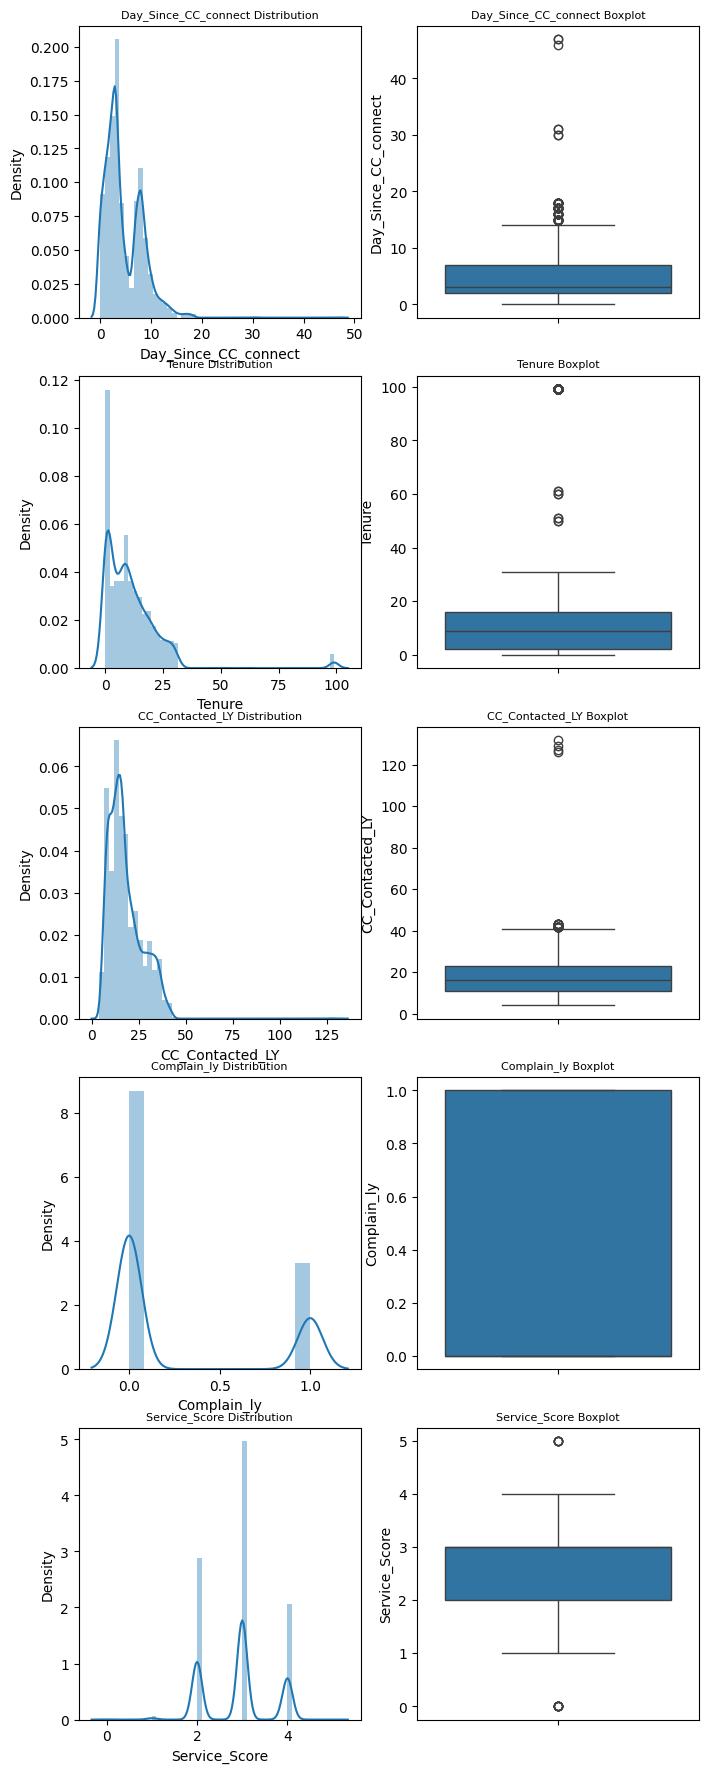

In [ ]:
#Univariate Analysis

fig, axes = plt.subplots(nrows=5,ncols=2)

fig.set_size_inches (8,22)

a = sns.distplot(df['Day_Since_CC_connect'], ax=axes[0][0])

a.set_title("Day_Since_CC_connect Distribution", fontsize=8)

a = sns.boxplot(df['Day_Since_CC_connect'], orient = "v", ax=axes[0][1])

a.set_title("Day_Since_CC_connect Boxplot", fontsize=8)


a = sns.distplot(df['Tenure'], ax=axes[1][0])

a.set_title("Tenure Distribution", fontsize=8)

a = sns.boxplot(df['Tenure'], orient = "v", ax=axes[1][1])

a.set_title("Tenure Boxplot", fontsize=8)


a = sns.distplot(df['CC_Contacted_LY'], ax=axes[2][0])

a.set_title("CC_Contacted_LY Distribution", fontsize=8)

a = sns.boxplot(df['CC_Contacted_LY'], orient = "v", ax=axes[2][1])

a.set_title("CC_Contacted_LY Boxplot", fontsize=8)


a = sns.distplot(df['Complain_ly'], ax=axes[3][0])

a.set_title("Complain_ly Distribution", fontsize=8)

a = sns.boxplot(df['Complain_ly'], orient = "v", ax=axes[3][1])

a.set_title("Complain_ly Boxplot", fontsize=8)


a = sns.distplot(df['Service_Score'], ax=axes[4][0])

a.set_title("Service_Score Distribution", fontsize=8)

a = sns.boxplot(df['Service_Score'], orient = "v", ax=axes[4][1])

a.set_title("Service_Score Boxplot", fontsize=8)

plt.show()

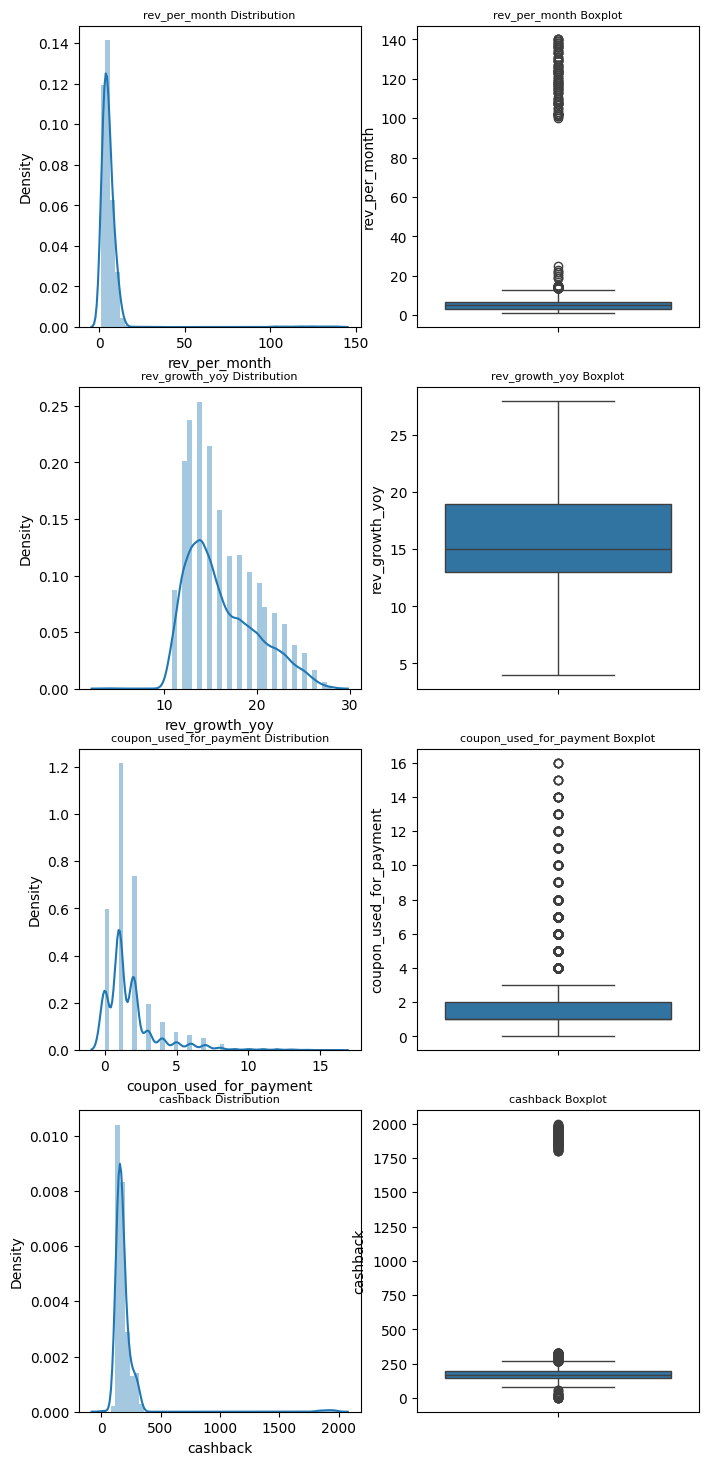

In [ ]:
fig, axes = plt.subplots(nrows=4,ncols=2)

fig.set_size_inches (8,18)

a = sns.distplot(df['rev_per_month'], ax=axes[0][0])

a.set_title("rev_per_month Distribution", fontsize=8)

a = sns.boxplot(df['rev_per_month'], orient = "v", ax=axes[0][1])

a.set_title("rev_per_month Boxplot", fontsize=8)


a = sns.distplot(df['rev_growth_yoy'], ax=axes[1][0])

a.set_title("rev_growth_yoy Distribution", fontsize=8)

a = sns.boxplot(df['rev_growth_yoy'], orient = "v", ax=axes[1][1])

a.set_title("rev_growth_yoy Boxplot", fontsize=8)


a = sns.distplot(df['coupon_used_for_payment'], ax=axes[2][0])

a.set_title("coupon_used_for_payment Distribution", fontsize=8)

a = sns.boxplot(df['coupon_used_for_payment'], orient = "v", ax=axes[2][1])

a.set_title("coupon_used_for_payment Boxplot", fontsize=8)


a = sns.distplot(df['cashback'], ax=axes[3][0])

a.set_title("cashback Distribution", fontsize=8)

a = sns.boxplot(df['cashback'], orient = "v", ax=axes[3][1])

a.set_title("cashback Boxplot", fontsize=8)

plt.show()

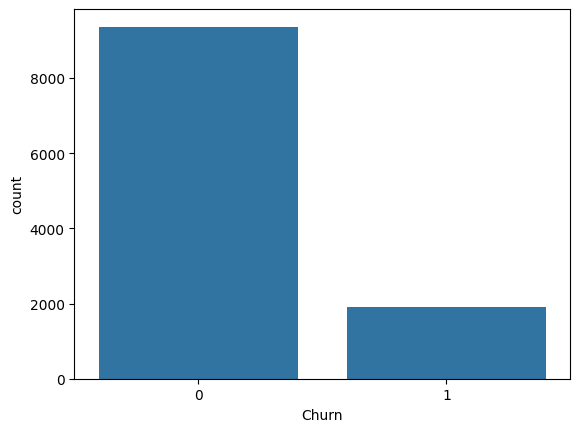

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

In [ ]:
print(df['Gender'].value_counts())

Gender
Male      6436
Female    4178
M          376
F          270
Name: count, dtype: int64


In [ ]:
# Replace short forms and inconsistent values
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female',
    'Male': 'Male',
    'Female': 'Female'
})

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,6812
Female,4448


In [ ]:
print(df['account_segment'].value_counts())

account_segment
Super           4159
Regular Plus    3862
HNI             1639
Super Plus       771
Regular          520
Regular +        262
Super +           47
Name: count, dtype: int64


In [ ]:
df['account_segment'] = df['account_segment'].replace({
    'Regular+': 'Regular Plus',
    'Super+': 'Super Plus',
    'Super +': 'Super Plus',
    'Regular +': 'Regular Plus'
})

In [ ]:
df['account_segment'].value_counts()

,count
account_segment,
Super,4159
Regular Plus,4124
HNI,1639
Super Plus,818
Regular,520


In [ ]:
df['Login_device'] = df['Login_device'].replace('&&&&', 'Other')

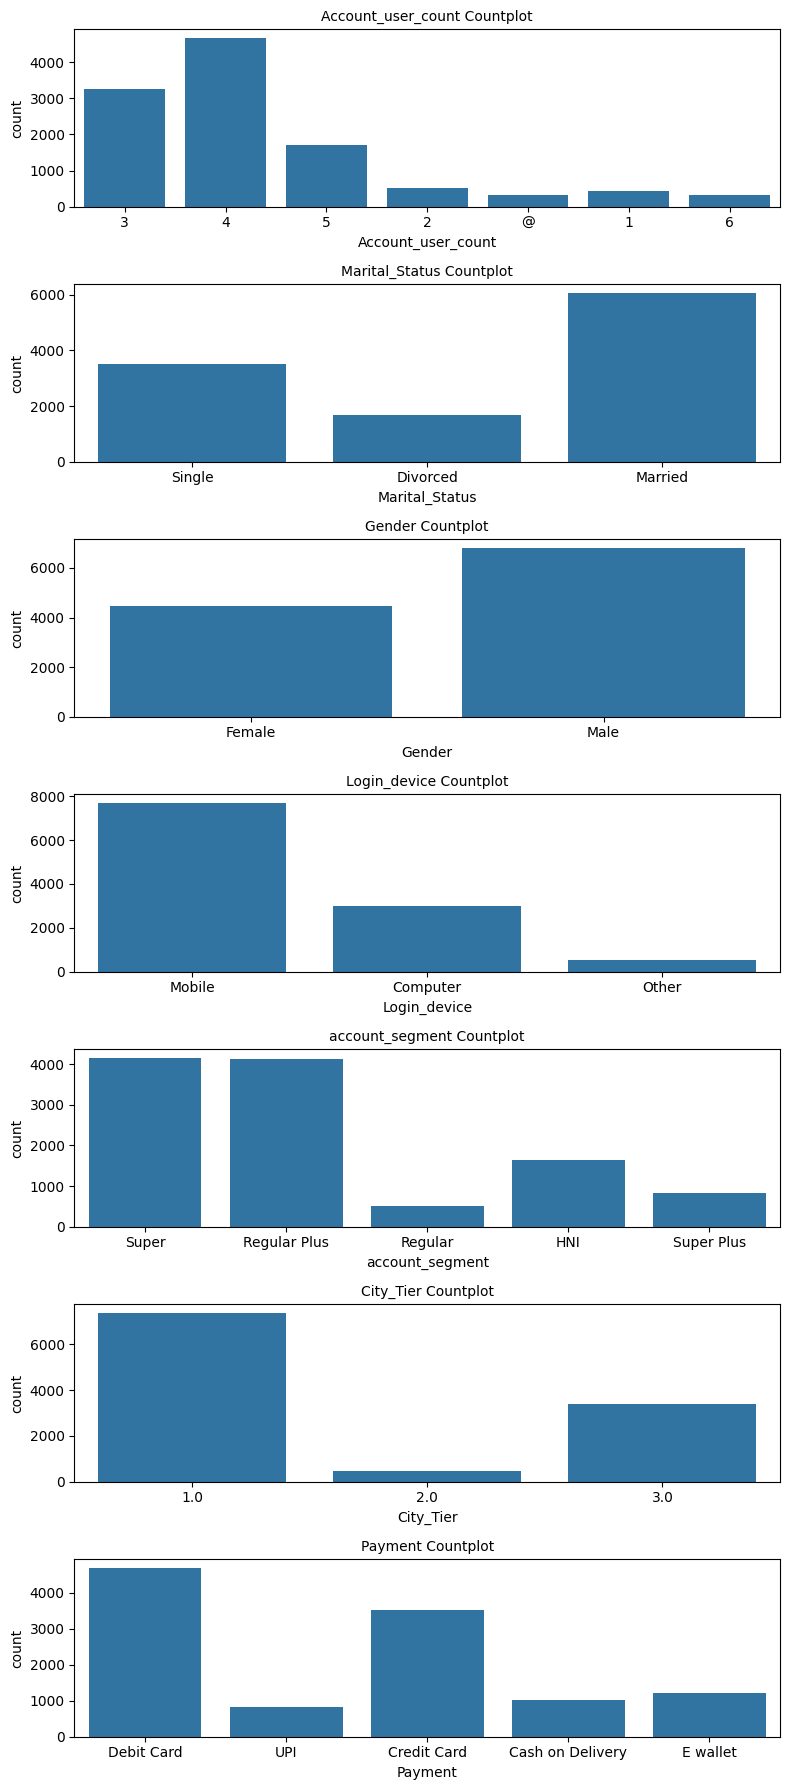

In [ ]:
fig, axes = plt.subplots(nrows=7,ncols=1)

fig.set_size_inches (8,18)

a = sns.countplot(data=df, x='Account_user_count', ax=axes[0])
a.set_title("Account_user_count Countplot", fontsize=10)

a = sns.countplot(data=df, x='Marital_Status', ax=axes[1])
a.set_title("Marital_Status Countplot", fontsize=10)

a = sns.countplot(data=df, x='Gender', ax=axes[2])
a.set_title("Gender Countplot", fontsize=10)

a = sns.countplot(data=df, x='Login_device', ax=axes[3])
a.set_title("Login_device Countplot", fontsize=10)

a = sns.countplot(data=df, x='account_segment', ax=axes[4])
a.set_title("account_segment Countplot", fontsize=10)

a = sns.countplot(data=df, x='City_Tier', ax=axes[5])
a.set_title("City_Tier Countplot", fontsize=10)

a = sns.countplot(data=df, x='Payment', ax=axes[6])
a.set_title("Payment Countplot", fontsize=10)

plt.tight_layout()
plt.show()

**Outlier Treatment**

In [ ]:
cols_to_cap = ['Tenure', 'rev_per_month', 'cashback', 'CC_Contacted_LY', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'Service_Score', 'CC_Agent_Score']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

Text(0.5, 1.0, 'Tenure Boxplot')

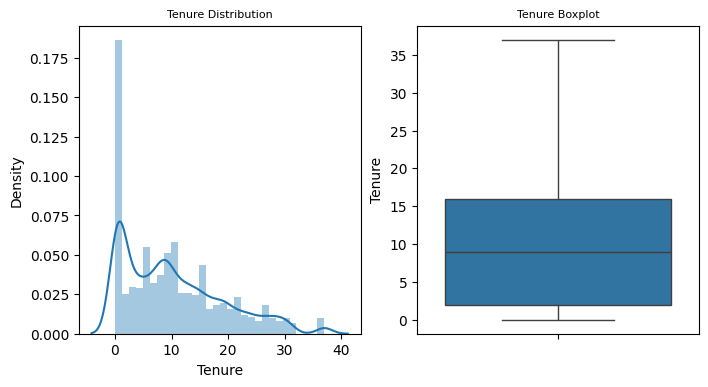

In [ ]:
fig, axes = plt.subplots(nrows=1,ncols=2)

fig.set_size_inches (8,4)

a = sns.distplot(df['Tenure'], ax=axes[0])
a.set_title("Tenure Distribution", fontsize=8)

a = sns.boxplot(df['Tenure'], orient = "v", ax=axes[1])

a.set_title("Tenure Boxplot", fontsize=8)

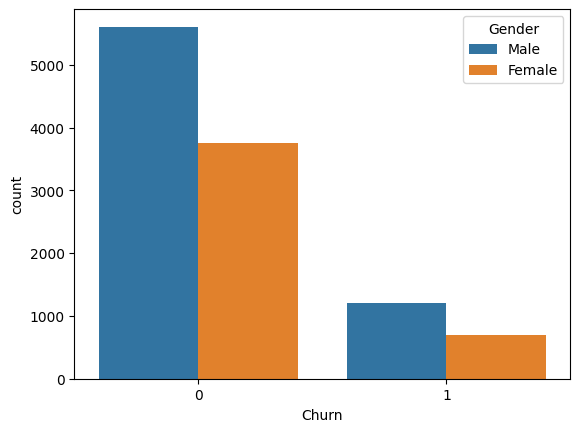

In [ ]:
#Bivariate Analysis

sns.countplot(x='Churn', hue='Gender', data=df);

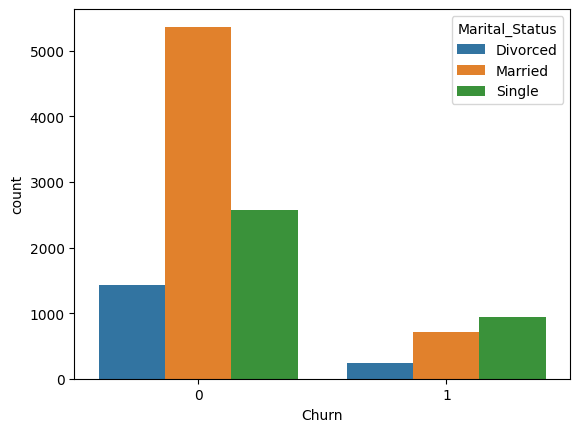

In [ ]:
sns.countplot(x='Churn', hue='Marital_Status', data=df);

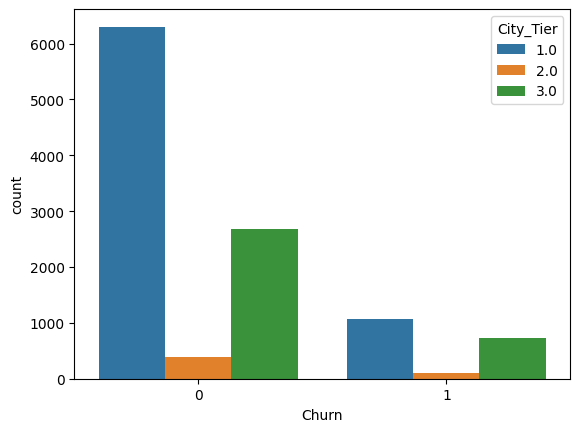

In [ ]:
sns.countplot(x='Churn', hue='City_Tier', data=df);

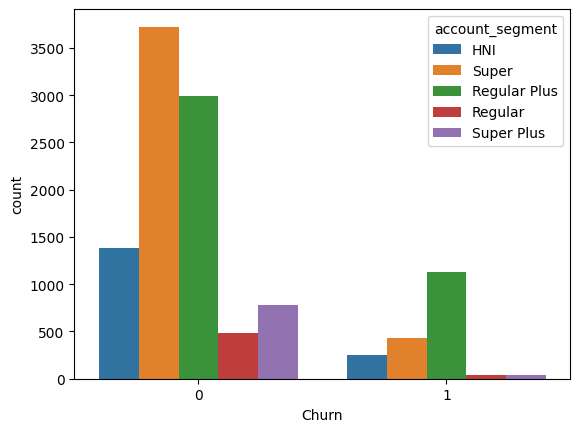

In [ ]:
sns.countplot(x='Churn', hue='account_segment', data=df);

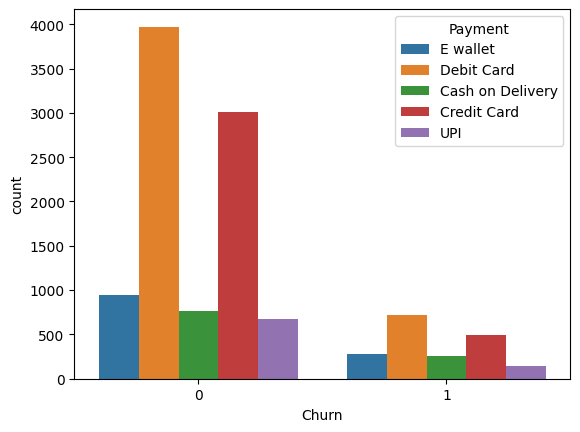

In [ ]:
sns.countplot(x='Churn', hue='Payment', data=df);

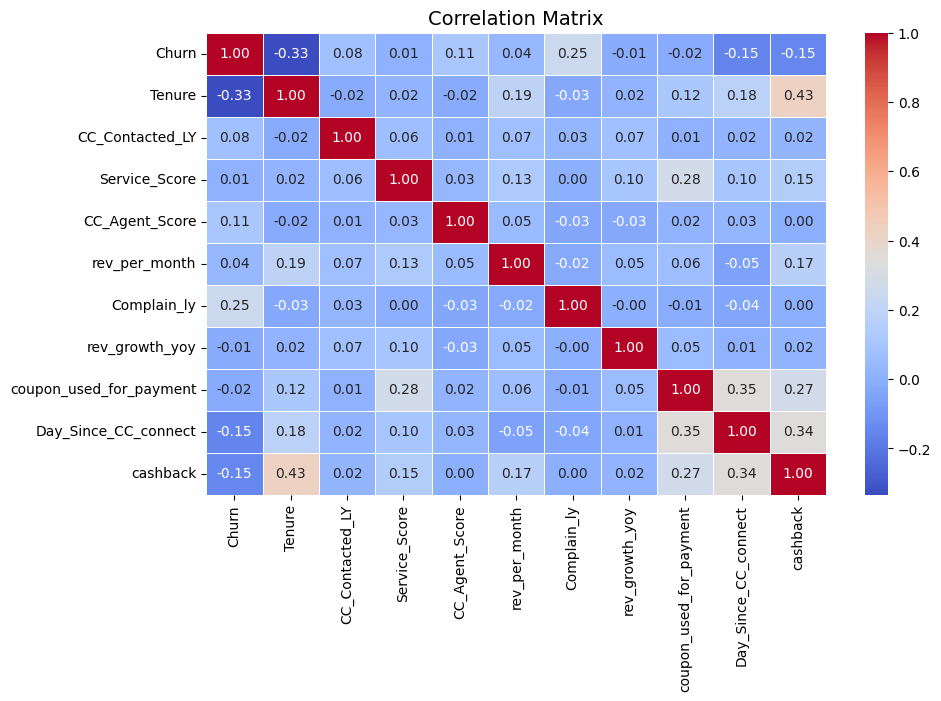

In [ ]:
#Correlation Matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

**One-Hot Encoding**

In [ ]:
#Identify all categorical columns (object or category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

#Apply One-Hot Encoding to all categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df=df.astype(int)
print(df.head())

Categorical columns: ['City_Tier', 'Payment', 'Gender', 'Account_user_count', 'account_segment', 'Marital_Status', 'Login_device']
   Churn  Tenure  CC_Contacted_LY  Service_Score  CC_Agent_Score  \
0      1       4                6              3               2   
1      1       0                8              3               3   
2      1       0               30              2               3   
3      1       0               15              2               5   
4      1       0               12              2               5   

   rev_per_month  Complain_ly  rev_growth_yoy  coupon_used_for_payment  \
0              9            1              11                        1   
1              7            1              15                        0   
2              6            1              14                        0   
3              8            0              23                        0   
4              3            0              11                        1   

   Day_Since_CC

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Churn                         11260 non-null  int64
 1   Tenure                        11260 non-null  int64
 2   CC_Contacted_LY               11260 non-null  int64
 3   Service_Score                 11260 non-null  int64
 4   CC_Agent_Score                11260 non-null  int64
 5   rev_per_month                 11260 non-null  int64
 6   Complain_ly                   11260 non-null  int64
 7   rev_growth_yoy                11260 non-null  int64
 8   coupon_used_for_payment       11260 non-null  int64
 9   Day_Since_CC_connect          11260 non-null  int64
 10  cashback                      11260 non-null  int64
 11  City_Tier_2.0                 11260 non-null  int64
 12  City_Tier_3.0                 11260 non-null  int64
 13  Payment_Credit Card           1

**Model Building & Evaluation**

In [ ]:
from sklearn import preprocessing

In [ ]:
X = df.drop("Churn", axis=1) #Features
y = df["Churn"] #Target

In [ ]:
numerical_cols

Index(['Churn', 'Tenure', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback'],
      dtype='object')

In [ ]:
from scipy.stats import zscore

In [ ]:
X[['Tenure', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']]=X[['Tenure', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score',
       'rev_per_month', 'Complain_ly', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']].apply(zscore)

In [ ]:
X.head()

,Tenure,CC_Contacted_LY,Service_Score,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,...,Account_user_count_6,Account_user_count_@,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,Login_device_Other
0,-0.703315,-1.379652,0.134545,-0.776488,1.302037,1.618461,-1.382201,-0.415366,0.132145,-0.396112,...,0,0,0,0,1,0,0,1,1,0
1,-1.153334,-1.146110,0.134545,-0.047944,0.607469,1.618461,-0.317551,-1.418588,-1.305768,-1.296820,...,0,0,0,1,0,0,0,1,1,0
2,-1.153334,1.422855,-1.251530,-0.047944,0.260185,1.618461,-0.583714,-1.418588,-0.443020,-0.280636,...,0,0,0,1,0,0,0,1,1,0
3,-1.153334,-0.328712,-1.251530,1.409143,0.954753,-0.617871,1.811748,-1.418588,-0.443020,-0.996584,...,0,0,0,0,1,0,0,1,1,0
4,-1.153334,-0.679025,-1.251530,1.409143,-0.781666,-0.617871,-1.382201,-0.415366,-0.443020,-1.088964,...,0,0,0,1,0,0,0,1,1,0


KNN Classification Model

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
#To calculate the accuracy score of the model
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model=KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
#Performance Matrix on train dataset
from sklearn import metrics
y_train_predict = KNN_model.predict(X_train)
model_score = KNN_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9712002029941639
[[6523   52]
 [ 175 1132]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      6575
           1       0.96      0.87      0.91      1307

    accuracy                           0.97      7882
   macro avg       0.96      0.93      0.95      7882
weighted avg       0.97      0.97      0.97      7882



In [ ]:
#Performance Matrix on test dataset
y_test_predict = KNN_model.predict(X_test)
model_score = KNN_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9322084073416222
[[2732   57]
 [ 172  417]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2789
           1       0.88      0.71      0.78       589

    accuracy                           0.93      3378
   macro avg       0.91      0.84      0.87      3378
weighted avg       0.93      0.93      0.93      3378



Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

LR_model=LogisticRegression()
LR_model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
#Performance Matrix on train dataset
from sklearn import metrics
y_train_predict = LR_model.predict(X_train)
model_score = LR_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.8887338239025628
[[6377  198]
 [ 679  628]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      6575
           1       0.76      0.48      0.59      1307

    accuracy                           0.89      7882
   macro avg       0.83      0.73      0.76      7882
weighted avg       0.88      0.89      0.88      7882



In [ ]:
#Performance Matrix on test dataset
y_test_predict = LR_model.predict(X_test)
model_score = LR_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8940201302545885
[[2709   80]
 [ 278  311]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2789
           1       0.80      0.53      0.63       589

    accuracy                           0.89      3378
   macro avg       0.85      0.75      0.79      3378
weighted avg       0.89      0.89      0.89      3378



Decision Tree Classification Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DT_model=DecisionTreeClassifier(max_depth=10, random_state=42)
DT_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
#Performance Matrix on train dataset
from sklearn import metrics
y_train_predict = DT_model.predict(X_train)
model_score = DT_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9720883024613043
[[6505   70]
 [ 150 1157]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      6575
           1       0.94      0.89      0.91      1307

    accuracy                           0.97      7882
   macro avg       0.96      0.94      0.95      7882
weighted avg       0.97      0.97      0.97      7882



In [ ]:
#Performance Matrix on test dataset
y_test_predict = DT_model.predict(X_test)
model_score = DT_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.923919478981646
[[2676  113]
 [ 144  445]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2789
           1       0.80      0.76      0.78       589

    accuracy                           0.92      3378
   macro avg       0.87      0.86      0.87      3378
weighted avg       0.92      0.92      0.92      3378



Support Vector Machine Model

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
#Performance Matrix on train dataset
from sklearn import metrics
y_train_predict = svm_model.predict(X_train)
model_score = svm_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.9335194113169246
[[6507   68]
 [ 456  851]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      6575
           1       0.93      0.65      0.76      1307

    accuracy                           0.93      7882
   macro avg       0.93      0.82      0.86      7882
weighted avg       0.93      0.93      0.93      7882



In [ ]:
#Performance Matrix on test dataset
y_test_predict = svm_model.predict(X_test)
model_score = svm_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.9194789816459443
[[2751   38]
 [ 234  355]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      2789
           1       0.90      0.60      0.72       589

    accuracy                           0.92      3378
   macro avg       0.91      0.79      0.84      3378
weighted avg       0.92      0.92      0.91      3378



**Model Evaluation Comparison**

In the model evaluation comparison, four Classification Models were assessed based on test accuracy values.
KNN Classification Model emerged as the best performer with the highest accuracy of 0.93, indicating it captures the most accurate prediction.

**Business Recommendations**

1. Targeted Retention Offers: Give small, personalized offers only to high-risk customers to avoid unnecessary cost.

2. Value-Based Packs: Introduce interest-based channel packs instead of discounts.

3. Service Improvement: Prioritize quick resolution and proactive communication for high-risk accounts.

4. Proactive Outreach: Contact high-risk customers early through calls/WhatsApp before they churn.

5. Loyalty Benefits: Provide light, low-cost perks to long-term customers (priority support, small rewards).

6. Payment Support: Send timely recharge reminders and simplify digital payments to prevent accidental churn.

**END**